# 1 · Los datos y su limpieza

Este cuaderno documenta **de dónde salen los datos y qué se les hace antes de
medir nada**. Cada decisión de limpieza se muestra con el antes y el después,
porque varias cambian los resultados de forma grande y nada obvia.

El orden es el de la tubería real (`boxbox_ml.ingest` → `boxbox_ml.features`),
así que lo que se ve acá es lo que efectivamente corre.

**Fuente:** FastF1 3.8.3 sobre el archivo de cronometraje oficial de la F1.
**Alcance:** temporadas 2022 a 2026, era de efecto suelo.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from boxbox_ml import cache, features, neutralisation, track_status

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9, 3.6), "figure.dpi": 110, "font.size": 9})

# La ingesta cruda tarda unos ocho minutos porque parsea el caché de FastF1
# sesión por sesión. Se guarda en parquet para que este cuaderno sea instantáneo.
PARQUET = cache.cache_dir().parent / "laps_overtaking.parquet"
raw = pd.read_parquet(PARQUET)
print(f"filas crudas: {len(raw):,}")
print(f"carreras:     {raw.groupby(['year', 'round']).ngroups}")
print(f"temporadas:   {sorted(raw['year'].unique())}")

filas crudas: 114,414
carreras:     103
temporadas:   [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 1.1 Qué trae una fila

Una fila es **un piloto en una vuelta**. FastF1 entrega el cronometraje por
sector, el estado del neumático, el estado de pista y una muestra de clima
alineada a esa vuelta.

In [2]:
raw[
    [
        "year",
        "round",
        "circuit",
        "Driver",
        "LapNumber",
        "Stint",
        "Compound",
        "TyreLife",
        "LapTime",
        "TrackStatus",
        "Position",
        "IsAccurate",
        "pit_in",
        "Rainfall",
    ]
].head(4)

,year,round,circuit,Driver,LapNumber,Stint,Compound,TyreLife,LapTime,TrackStatus,Position,IsAccurate,pit_in,Rainfall
0,2022,1,Sakhir,VER,1.0,1.0,SOFT,4.0,100.236,1,2.0,False,False,False
1,2022,1,Sakhir,VER,2.0,1.0,SOFT,5.0,97.880,1,2.0,True,False,False
2,2022,1,Sakhir,VER,3.0,1.0,SOFT,6.0,98.357,1,2.0,True,False,False
3,2022,1,Sakhir,VER,4.0,1.0,SOFT,7.0,98.566,1,2.0,True,False,False


## 1.2 Tres trampas del formato

Ninguna está documentada de forma prominente y las tres producen resultados
equivocados en silencio.

### Trampa 1 · `TrackStatus` es una cadena concatenada, no un código

Cuando en una vuelta se solapan dos estados, FastF1 devuelve **los dígitos
pegados**. Un `"45"` no es el estado cuarenta y cinco: es «safety car» (4) y
«bandera roja» (5) en la misma vuelta. Compararlo por igualdad pierde todo lo
que no sea un estado puro.

In [3]:
counts = raw["TrackStatus"].astype(str).value_counts().head(12)
print("valores más frecuentes de TrackStatus:")
print(counts.to_string())

pure = raw["TrackStatus"].astype(str).str.len().eq(1)
compuestos = [v for v in counts.index if len(str(v)) > 1]
print(f"\nvalores compuestos entre los 12 más frecuentes: {compuestos}")
print(f"vueltas con estado compuesto: {(~pure).sum():,} de {len(raw):,} ({(~pure).mean():.1%})")
print("Compararlas por igualdad las perdería a todas.")

valores más frecuentes de TrackStatus:
TrackStatus
1      101929
12       3487
4        3225
41       1118
124       869
671       734
126       479
21        358
6         299
26        251
24        232
16        221

valores compuestos entre los 12 más frecuentes: ['12', '41', '124', '671', '126', '21', '26', '24', '16']
vueltas con estado compuesto: 8,878 de 114,414 (7.8%)
Compararlas por igualdad las perdería a todas.


In [4]:
# `track_status.add_flags` decodifica por dígito contenido, no por igualdad.
flagged = track_status.add_flags(raw)
print(
    flagged[["yellow", "sc", "vsc", "vsc_ending", "red", "is_neutralised"]]
    .mean()
    .mul(100)
    .round(2)
    .rename("% de vueltas")
    .to_string()
)

yellow            5.33
sc                5.24
vsc               2.19
vsc_ending        1.05
red               0.23
is_neutralised    7.29


### Trampa 2 · El nombre del circuito no es estable entre temporadas

`Location` cambia de una temporada a otra para el mismo circuito. Agrupar por
ese campo parte un circuito en dos y arruina cualquier tasa por circuito.

In [5]:
por_circuito = flagged.groupby("circuit")["year"].agg(temporadas=lambda s: sorted(s.unique()))
sospechosos = por_circuito[por_circuito["temporadas"].map(len) <= 2]
print("circuitos presentes en dos temporadas o menos (candidatos a alias):")
print(sospechosos.to_string())
print(f"\nalias que aplica el proyecto: {neutralisation.CIRCUIT_ALIASES}")

circuitos presentes en dos temporadas o menos (candidatos a alias):
                 temporadas
circuit                    
Le Castellet         [2022]
Miami Gardens  [2025, 2026]
Monte Carlo          [2026]

alias que aplica el proyecto: {'Monte Carlo': 'Monaco', 'Miami Gardens': 'Miami', 'Montreal': 'Montréal', 'Sao Paulo': 'São Paulo', 'Mexico': 'Mexico City', 'Abu Dhabi': 'Yas Island'}


In [6]:
canon = flagged.copy()
canon["circuit"] = canon["circuit"].map(lambda c: neutralisation.CIRCUIT_ALIASES.get(c, c))
print(f"circuitos antes del alias:  {flagged['circuit'].nunique()}")
print(f"circuitos después:          {canon['circuit'].nunique()}")

circuitos antes del alias:  27
circuitos después:          25


### Trampa 3 · El límite de peticiones trunca en silencio

FastF1 corta a las 500 llamadas por hora. Al pasarse **no falla**: devuelve
sesiones vacías y la ingesta sigue como si nada. Una corrida temprana de este
proyecto quedó con 2023 y 2024 a medio cargar y 2025 ausente, y el caché
incompleto sesgó la degradación del blando de 2023 un **60%**, de 0,0664 a
0,0403 s/vuelta.

La defensa es contar carreras por temporada antes de creerle a nada.

In [7]:
por_temporada = canon.groupby("year").agg(
    carreras=("round", "nunique"),
    vueltas=("LapNumber", "size"),
    pilotos=("Driver", "nunique"),
)
por_temporada["esperadas"] = [22, 22, 24, 24, 24]
por_temporada["completa"] = por_temporada["carreras"] >= por_temporada["esperadas"] - 1
por_temporada

,carreras,vueltas,pilotos,esperadas,completa
year,,,,,
2022,22,23577,22,22,True
2023,21,23449,22,22,True
2024,24,26604,24,24,True
2025,24,26689,21,24,True
2026,12,14095,23,24,False


2026 tiene 12 carreras porque **la temporada está en curso**, no porque falte
nada. Las otras cuatro están completas.

## 1.3 Qué vuelta sirve para medir ritmo

La mayoría de las vueltas de una carrera **no describen ritmo de carrera**. Se
marcan cuatro clases como no representativas, y se dejan en la tabla en vez de
borrarlas: la vuelta de entrada a boxes es exactamente donde vive la etiqueta
que el modelo quiere predecir.

In [8]:
marked = features.mark_representative(canon)
razones = pd.DataFrame(
    {
        "sin LapTime": marked["LapTime"].isna(),
        "IsAccurate falso": ~marked["IsAccurate"].eq(True),
        "borrada por comisarios": marked["Deleted"].eq(True),
        "entrada a boxes": marked["pit_in"].astype(bool),
        "salida de boxes": marked["pit_out"].astype(bool),
    }
)
resumen = razones.sum().rename("vueltas").to_frame()
resumen["% del total"] = (resumen["vueltas"] / len(marked) * 100).round(2)
print(resumen.to_string())
print(
    f"\nrepresentativas: {marked['is_representative'].sum():,} de {len(marked):,} "
    f"({marked['is_representative'].mean():.1%})"
)

                        vueltas  % del total
sin LapTime                1762         1.54
IsAccurate falso          15868        13.87
borrada por comisarios        0         0.00
entrada a boxes            3970         3.47
salida de boxes            3949         3.45

representativas: 98,546 de 114,414 (86.1%)


## 1.4 Corrección de combustible

Un auto que lleva combustible para `n` vueltas más es aproximadamente
`beta * n` segundos más lento. Sin descontarlo, toda vuelta tardía parece
rápida y toda vuelta temprana parece lenta, y la degradación queda enmascarada.

**Es la suposición más débil del proyecto.** `beta = 0,035 s/vuelta` es una
constante calibrada sobre la era anterior, no un parámetro ajustado a 2026.

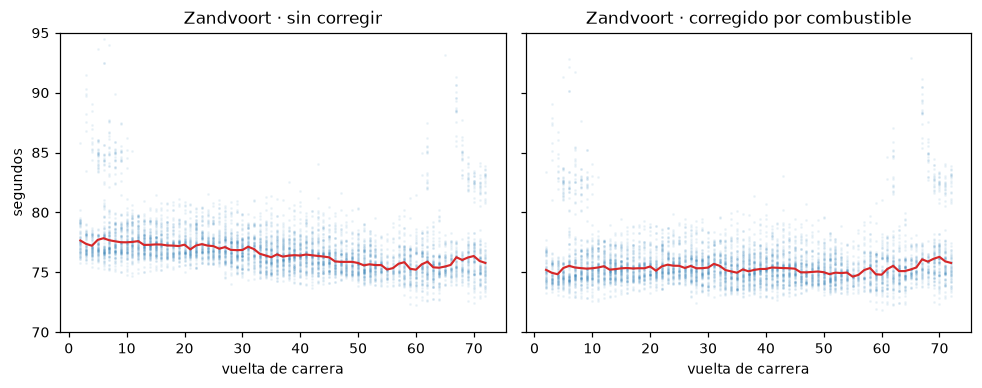

In [9]:
fuelled = features.add_fuel_correction(marked)
rep = fuelled[fuelled["is_representative"]]
zand = rep[rep["circuit"] == "Zandvoort"]

fig, axes = plt.subplots(1, 2, sharey=True)
for ax, columna, titulo in (
    (axes[0], "LapTime", "sin corregir"),
    (axes[1], "lap_time_fuel_corrected", "corregido por combustible"),
):
    ax.scatter(zand["LapNumber"], zand[columna], s=1, alpha=0.06, color="#1f77b4")
    tendencia = zand.groupby("LapNumber")[columna].median()
    ax.plot(tendencia.index, tendencia.to_numpy(), color="#d62728", lw=1.4)
    ax.set_title(f"Zandvoort · {titulo}")
    ax.set_xlabel("vuelta de carrera")
    ax.set_ylim(70, 95)
axes[0].set_ylabel("segundos")
plt.tight_layout()
plt.show()

In [10]:
for columna, etiqueta in (("LapTime", "sin corregir"), ("lap_time_fuel_corrected", "corregido")):
    tendencia = zand.groupby("LapNumber")[columna].median()
    pendiente = np.polyfit(tendencia.index, tendencia.to_numpy(), 1)[0]
    print(f"{etiqueta:12s} pendiente {pendiente:+.4f} s por vuelta de carrera")

print("\nSi la corrección fuera exacta, la pendiente corregida sería del orden del")
print("desgaste medio y positiva. Que quede cerca de cero o negativa es la señal")
print("de que beta corrige de menos, y es la causa de que la mitad de la parrilla")
print("aparezca con degradación plana o mejorando a mitad de carrera.")

sin corregir pendiente -0.0337 s por vuelta de carrera
corregido    pendiente +0.0013 s por vuelta de carrera

Si la corrección fuera exacta, la pendiente corregida sería del orden del
desgaste medio y positiva. Que quede cerca de cero o negativa es la señal
de que beta corrige de menos, y es la causa de que la mitad de la parrilla
aparezca con degradación plana o mejorando a mitad de carrera.


## 1.5 La fuga de datos que hubo que tapar

`degradation_s` se calcula contra una vuelta de referencia de la propia tanda.
En la primera versión **el valor de la vuelta actual entraba como predictor de
lo que pasaba en esa misma vuelta**. Como la vuelta de entrada a boxes no es
representativa, su degradación quedaba nula, y el modelo aprendía a leer eso en
vez de aprender estrategia.

In [11]:
featured = features.add_labels(features.add_degradation(fuelled))
fuga = pd.DataFrame(
    {
        "con degradation_s definida": [
            featured.loc[~featured["boxed"], "degradation_s"].notna().mean(),
            featured.loc[featured["boxed"], "degradation_s"].notna().mean(),
        ]
    },
    index=["vueltas normales", "vueltas de entrada a boxes"],
)
print((fuga * 100).round(1).to_string())
print("\nUna columna presente en casi todas las vueltas de un grupo y en ninguna")
print("del otro no es un predictor: es la etiqueta escrita al revés. La tubería")
print("la desplaza una vuelta antes de usarla para entrenar.")

                            con degradation_s definida
vueltas normales                                  89.2
vueltas de entrada a boxes                         0.0

Una columna presente en casi todas las vueltas de un grupo y en ninguna
del otro no es un predictor: es la etiqueta escrita al revés. La tubería
la desplaza una vuelta antes de usarla para entrenar.


## 1.6 Paradas que no fueron decisiones

Un cambio de gomas con la carrera **detenida por bandera roja** no cuesta los
~23 segundos que este proyecto modela: es gratis. Contarlas como estrategia
enseña que parar a veces no cuesta nada.

In [12]:
paradas = featured[featured["boxed"] & (featured["LapNumber"] > 1)]
por_anio = paradas.groupby("year")["free_stop"].agg(paradas="size", gratis="mean")
por_anio["gratis %"] = (por_anio["gratis"] * 100).round(1)
print(por_anio[["paradas", "gratis %"]].to_string())

peores = (
    paradas.groupby(["year", "round", "circuit"])["free_stop"]
    .agg(paradas="size", gratis="mean")
    .sort_values("gratis", ascending=False)
    .head(5)
)
peores["gratis %"] = (peores["gratis"] * 100).round(1)
print("\ncarreras con mayor proporción de paradas gratis:")
print(peores[["paradas", "gratis %"]].to_string())

      paradas  gratis %
year                   
2022      812       4.4
2023      870      12.6
2024      808       2.2
2025      827       0.0
2026      515       7.2

carreras con mayor proporción de paradas gratis:
                        paradas  gratis %
year round circuit                       
2023 3     Melbourne         60      81.7
2024 21    São Paulo         36      50.0
2022 18    Suzuka            41      43.9
2023 19    Mexico City       41      43.9
2022 7     Monaco            53      34.0


El caso que obligó a separarlas es Zandvoort 2026: **21 de 22 autos «pararon»
en la vuelta 2** detrás de una bandera roja. Sin el filtro, esa carrera enseña
que parar temprano es gratis y frecuente.

In [13]:
z26 = featured[(featured["year"] == 2026) & (featured["circuit"] == "Zandvoort")]
temprano = z26[z26["boxed"] & (z26["LapNumber"] <= 3)]
print(f"autos que 'pararon' en las tres primeras vueltas: {temprano['Driver'].nunique()}")
print(f"de esas paradas, gratis bajo bandera roja: {int(temprano['free_stop'].sum())} de {len(temprano)}")

autos que 'pararon' en las tres primeras vueltas: 21
de esas paradas, gratis bajo bandera roja: 21 de 21


## 1.7 La lluvia

Una carrera mojada reordena la parrilla por motivos que pertenecen al clima, no
al trazado ni a la estrategia. Se descarta **entera**, no vuelta por vuelta:
una pista secándose sigue produciendo adelantamientos y paradas mucho después
de que dejó de llover.

In [14]:
lluvia = featured.groupby(["year", "round"])["Rainfall"].mean()
mojadas = lluvia[lluvia > 0.2]
tabla = mojadas.rename("lluvia").to_frame()
tabla["circuito"] = [
    featured[(featured["year"] == y) & (featured["round"] == r)]["circuit"].iloc[0]
    for y, r in mojadas.index
]
tabla["lluvia %"] = (tabla["lluvia"] * 100).round(0)
print(
    f"carreras con lluvia en más del 20% de las vueltas: {len(mojadas)} de "
    f"{featured.groupby(['year', 'round']).ngroups}"
)
print(tabla[["circuito", "lluvia %"]].to_string())

carreras con lluvia en más del 20% de las vueltas: 8 de 103
               circuito  lluvia %
year round                       
2022 7           Monaco      39.0
     13        Budapest      29.0
     18          Suzuka      90.0
2023 13       Zandvoort      23.0
2024 9         Montréal      25.0
     12     Silverstone      43.0
     21       São Paulo      73.0
2025 1        Melbourne      33.0


El efecto sobre una medición concreta —cambios de posición por vuelta en verde,
en Zandvoort, medido en el cuaderno 2:

| Temporada | Cambios por vuelta |
|---|---|
| 2022 seca | 0,302 |
| **2023 mojada** | **1,121** |
| 2024 seca | 0,507 |
| 2025 seca | 0,472 |
| 2026 seca | 0,727 |

La carrera mojada marca 3,7 veces la seca sobre el mismo asfalto. Con ella
adentro Zandvoort era el 12.º circuito más difícil de 25; sin ella, el 5.º.
Una sola carrera movía siete puestos.

## 1.8 Las vueltas neutralizadas, y un filtro que resultó redundante

Bajo safety car, VSC o bandera roja el orden cambia por motivos que no son
carrera, y adelantar está prohibido. Toda medición de ritmo las excluye.

Cuánto pesan, sobre las vueltas cronometradas que no tocan boxes:

In [15]:
crono = featured[
    featured["LapTime"].notna()
    & ~featured["pit_in"].astype(bool)
    & ~featured["pit_out"].astype(bool)
]
comparacion = crono.groupby("is_neutralised")["LapTime"].agg(
    vueltas="size", mediana="median", media="mean"
)
comparacion.index = ["verde", "neutralizada"]
print(comparacion.round(2).to_string())
delta = comparacion.loc["neutralizada", "mediana"] - comparacion.loc["verde", "mediana"]
print(f"\ndiferencia de mediana: {delta:+.1f} s por vuelta")
print("Dejarlas adentro arrasa con cualquier promedio de ritmo.")

              vueltas  mediana   media
verde          100217    86.97   88.91
neutralizada     5394   116.73  116.57

diferencia de mediana: +29.8 s por vuelta
Dejarlas adentro arrasa con cualquier promedio de ritmo.


Ahora lo inesperado. Al escribir este cuaderno la comparación falló porque el
`groupby` devolvía **un solo grupo**: entre las vueltas representativas no hay
ni una neutralizada.

In [16]:
solapamiento = pd.crosstab(
    featured["is_representative"].rename("representativa"),
    featured["is_neutralised"].rename("neutralizada"),
)
print(solapamiento.to_string())
print(
    "\nvueltas representativas Y neutralizadas: "
    f"{int((featured['is_representative'] & featured['is_neutralised']).sum())}"
)

neutralizada    False  True 
representativa              
False            7523   8345
True            98546      0

vueltas representativas Y neutralizadas: 0


**El `IsAccurate` de FastF1 ya descarta todas las vueltas neutralizadas.** Los
dos filtros se solapan por completo, así que para medir ritmo el filtro de
neutralización no quita nada que el otro no haya quitado ya.

No es motivo para sacarlo. Sigue haciendo falta para las mediciones que **no**
usan `is_representative` —el conteo de adelantamientos trabaja sobre
`Position`, no sobre tiempos, y ahí sí hay vueltas neutralizadas que
descontar— y depender de un efecto lateral de una bandera de otra librería
sería frágil. Pero conviene saber que en la tubería de ritmo es redundante, en
vez de atribuirle un efecto que no tiene.

## 1.9 El embudo completo

In [17]:
total = len(featured)
verde_rep = featured["is_representative"] & ~featured["is_neutralised"] & ~featured["red"]
sin_lluvia = ~pd.MultiIndex.from_frame(featured[["year", "round"]]).isin(set(mojadas.index))

embudo = pd.DataFrame(
    [
        ("ingesta cruda", total, "todo lo que devuelve FastF1"),
        ("con LapTime", int(featured["LapTime"].notna().sum()), "descarta vueltas sin cronometrar"),
        (
            "representativas",
            int(featured["is_representative"].sum()),
            "sin boxes, sin borradas, IsAccurate",
        ),
        ("+ sólo verde", int(verde_rep.sum()), "sin SC, VSC ni bandera roja"),
        ("+ sin lluvia", int((verde_rep & sin_lluvia).sum()), "descarta 8 carreras enteras"),
    ],
    columns=["paso", "vueltas", "para qué"],
)
embudo["% del crudo"] = (embudo["vueltas"] / total * 100).round(1)
embudo

,paso,vueltas,para qué,% del crudo
0,ingesta cruda,114414,todo lo que devuelve FastF1,100.0
1,con LapTime,112652,descarta vueltas sin cronometrar,98.5
2,representativas,98546,"sin boxes, sin borradas, IsAccurate",86.1
3,+ sólo verde,98546,"sin SC, VSC ni bandera roja",86.1
4,+ sin lluvia,91609,descarta 8 carreras enteras,80.1


Queda alrededor de **dos tercios de las vueltas crudas** para medir ritmo. El
tercio restante no se tira: las vueltas de boxes son la etiqueta, y las
neutralizadas son el objeto de estudio de la mitad del proyecto.

Las mediciones que se apoyan en esta base están en `02-mediciones.ipynb`.